In [2]:
import pandas as pd 
import numpy as np 

In [3]:
import pdfplumber

rows = []

with pdfplumber.open("esp_basilikum.pdf") as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        lines = text.split("\n")

        for line in lines:
            # skip header or empty lines
            if "timestamp" in line.lower() or line.strip() == "":
                continue

            parts = line.split()

            # Expect 6 columns:
            # date time temp humidity soil_raw soil_moisture
            if len(parts) >= 6:
                timestamp = parts[0] + " " + parts[1]
                temperature = parts[2]
                humidity = parts[3]
                soil_raw = parts[4]
                soil_moisture = parts[5]

                rows.append([timestamp, temperature, humidity, soil_raw, soil_moisture])

df = pd.DataFrame(rows, columns=[
    "timestamp", "temperature", "humidity", "soil_raw", "soil_moisture"
])

# convert types
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.astype({
    "temperature": float,
    "humidity": float,
    "soil_raw": int,
    "soil_moisture": int
})

df.to_csv("basilikum_sensor.csv", index=False)

In [4]:
basil_sensor_data = pd.read_csv("basilikum_sensor.csv")
basil_sensor_data.head()

,timestamp,temperature,humidity,soil_raw,soil_moisture
0,2026-03-02 22:49:31,25.0,60.0,1674,93
1,2026-03-02 22:50:37,25.0,60.0,1676,93
2,2026-03-02 22:51:42,25.0,60.0,1674,93
3,2026-03-02 22:52:48,25.0,60.0,1687,92
4,2026-03-02 22:53:52,25.0,60.0,1667,93


In [5]:
import matplotlib.pyplot as plt



array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

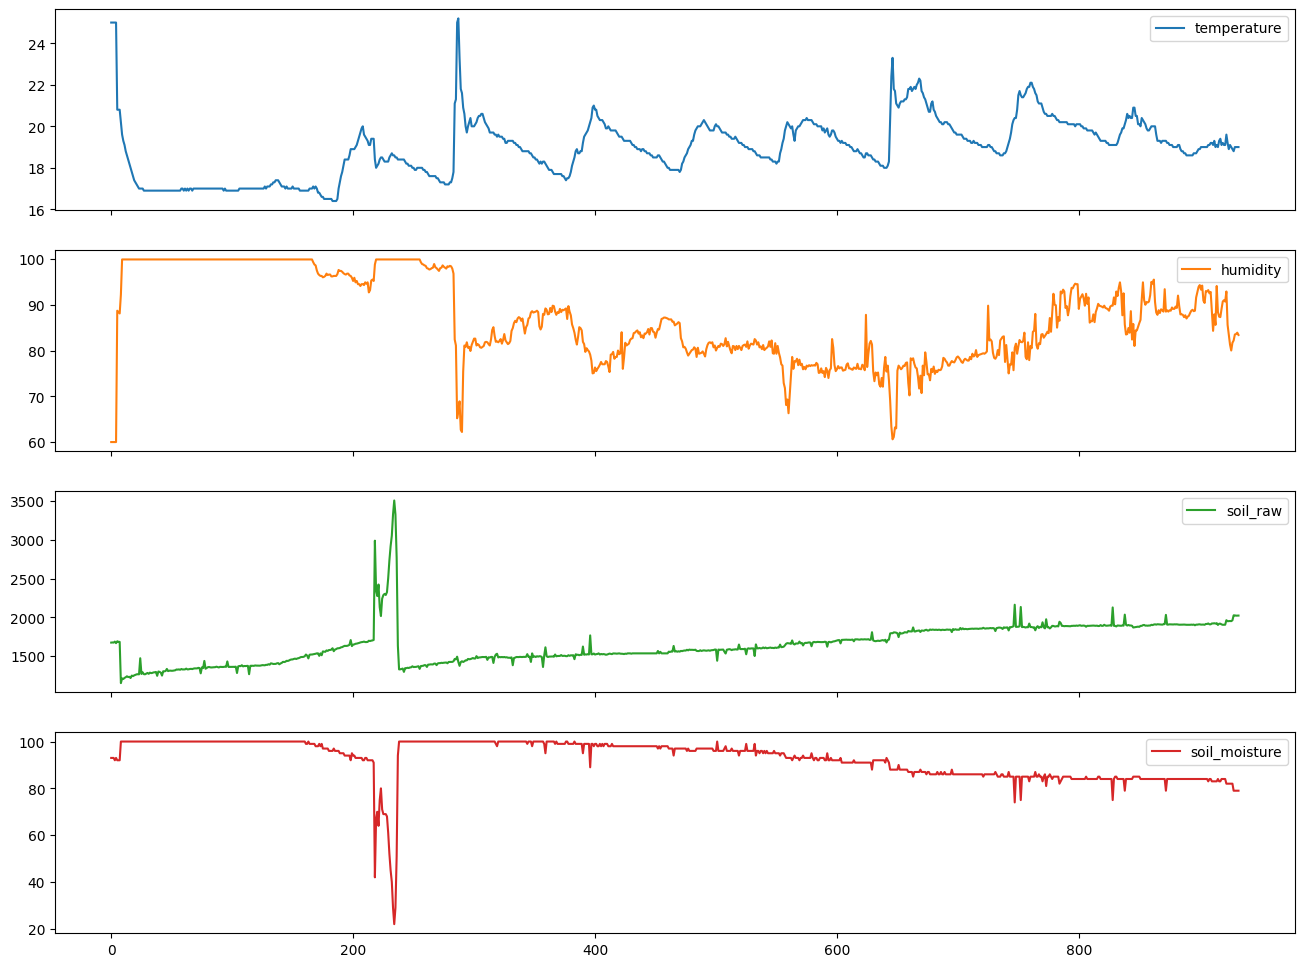

In [6]:
basil_sensor_data.plot(kind='line', subplots=True,figsize=(16,12))

For an ESP32 device, the optimal values for monitoring basil depend on correctly calibrating your sensors to account for the ESP32's 12-bit ADC (0–4095 range). [1] 
## 1. Soil Moisture (0–100% Scale) [1] 
On a calibrated 0–100% scale (where 100% is saturated and 0% is air-dry), target these levels:

* Optimal Range: 60% – 80%. This keeps the soil "consistently moist," which is essential for high biomass and flavorful leaves.
* Watering Trigger: < 40% – 50%. Program your ESP32 to send an alert or trigger irrigation when the level drops into this range to avoid wilting.
* Critical Wet: > 90%. Avoid this to prevent root rot and downy mildew.
* Calibration Tip: Use the map() function to flip your raw analog units (1500–3500) into this percentage:
* moisture_pct = map(analogRead(pin), 3500, 1500, 0, 100);. [2, 3, 4, 5, 6] 

## 2. Air Temperature
Basil is a warm-season herb and is highly sensitive to cold. [7, 8] 

* Optimal (Day): 21°C – 32°C (70°F – 90°F).
* Optimal (Night): Above 15°C (59°F).
* Critical Low Alert: < 10°C (50°F). Set a sensor threshold to alert you if temperatures drop this low, as it can cause permanent chilling injury.
* Critical High Alert: > 38°C (100°F). High heat without extreme moisture will cause rapid bolting (flowering) or death. [7, 8, 9, 10, 11] 

## 3. Relative Humidity (RH)

* Optimal Range: 40% – 60%. This provides enough moisture for the leaves without encouraging disease.
* High Humidity Alert: > 70% – 85%. If your sensor (like a DHT22) records sustained humidity above 70%—especially at night—it significantly increases the risk of downy mildew. [4, 8, 12] 

## Summary for ESP32 Logic

| Metric [5, 8] | Target Range | Alert Trigger (Low) | Alert Trigger (High) |
|---|---|---|---|
| Soil Moisture | 60 – 80% | < 45% (Dry) | > 90% (Saturated) |
| Temperature | 21 – 29°C | < 13°C (Cold) | > 35°C (Heat Stress) |
| Humidity | 40 – 60% | < 30% (Low) | > 75% (Fungal Risk) |




In [7]:
basil_sensor_data['hrs_min_sec'] = basil_sensor_data['timestamp'].apply(lambda x: x.split()[1])
basil_sensor_data['hrs'] = basil_sensor_data['hrs_min_sec'].apply(lambda x: x.split(":")[0])

# basil_sensor_data['season'] = "winter"
# basil_sensor_data['day_night'] = np.where( basil_sensor_data['hrs'] < '17', 'day', 'night')
basil_sensor_data


,timestamp,temperature,humidity,soil_raw,soil_moisture,hrs_min_sec,hrs
0,2026-03-02 22:49:31,25.0,60.0,1674,93,22:49:31,22
1,2026-03-02 22:50:37,25.0,60.0,1676,93,22:50:37,22
2,2026-03-02 22:51:42,25.0,60.0,1674,93,22:51:42,22
3,2026-03-02 22:52:48,25.0,60.0,1687,92,22:52:48,22
4,2026-03-02 22:53:52,25.0,60.0,1667,93,22:53:52,22
...,...,...,...,...,...,...,...
928,2026-03-14 19:55:42,18.8,82.2,2026,79,19:55:42,19
929,2026-03-14 19:58:31,19.0,83.5,2025,79,19:58:31,19
930,2026-03-14 19:58:44,19.0,83.6,2022,79,19:58:44,19
931,2026-03-14 19:59:21,19.0,83.9,2023,79,19:59:21,19


In [8]:
basil_sensor_data['health_based_on_photos'] = 'good'
basil_sensor_data['health_based_on_photos'][:229] = 'good'
basil_sensor_data['health_based_on_photos'][229:326] = 'moderate'
basil_sensor_data['health_based_on_photos'][326:507] = 'good'
basil_sensor_data['health_based_on_photos'][507:779] = 'moderate'
basil_sensor_data['health_based_on_photos'][779:] = 'critical'

C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\2994023356.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  basil_sensor_data['health_based_on_photos'][:229] = 'good'
C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\299

In [9]:
basil_sensor_data['health_based_on_photos'].value_counts()

health_based_on_photos
good        410
moderate    369
critical    154
Name: count, dtype: int64

In [10]:
basil_min_temp_day_opt = 21
basil_max_temp_day_opt = 32
basil_avg_temp_day_opt = (basil_min_temp_day_opt + basil_max_temp_day_opt) / 2

# basil_min_temp_night_opt = 15
# basil_max_temp_night_opt = 32
# basil_avg_temp_night_opt = (basil_min_temp_night_opt + basil_max_temp_night_opt) /2


basil_min_hum_opt = 40
basil_max_hum_opt = 60
basil_avg_hum_opt = (basil_min_hum_opt + basil_max_hum_opt) / 2

basil_min_soil_moisture_opt = 60
basil_max_soil_moisture_opt = 80
basil_avg_soil_mositure_opt = (basil_min_soil_moisture_opt + basil_max_soil_moisture_opt) /2





In [11]:
basil_sensor_data['rel_temp_day_diff_from_opt'] = abs((basil_sensor_data['temperature'] - basil_avg_temp_day_opt)/basil_avg_temp_day_opt)
# basil_sensor_data['rel_temp_night_diff_from_opt'] = abs((basil_sensor_data['temperature'] - basil_avg_temp_night_opt)/basil_avg_temp_night_opt)
basil_sensor_data['rel_hum_diff_from_opt'] = abs((basil_sensor_data['humidity'] - basil_avg_hum_opt)/basil_avg_hum_opt)
basil_sensor_data['rel_soil_moisture_diff_from_opt'] = abs((basil_sensor_data['soil_moisture'] - basil_avg_soil_mositure_opt)/basil_avg_soil_mositure_opt)


In [12]:
basil_sensor_data

,timestamp,temperature,humidity,soil_raw,soil_moisture,hrs_min_sec,hrs,health_based_on_photos,rel_temp_day_diff_from_opt,rel_hum_diff_from_opt,rel_soil_moisture_diff_from_opt
0,2026-03-02 22:49:31,25.0,60.0,1674,93,22:49:31,22,good,0.056604,0.200,0.328571
1,2026-03-02 22:50:37,25.0,60.0,1676,93,22:50:37,22,good,0.056604,0.200,0.328571
2,2026-03-02 22:51:42,25.0,60.0,1674,93,22:51:42,22,good,0.056604,0.200,0.328571
3,2026-03-02 22:52:48,25.0,60.0,1687,92,22:52:48,22,good,0.056604,0.200,0.314286
4,2026-03-02 22:53:52,25.0,60.0,1667,93,22:53:52,22,good,0.056604,0.200,0.328571
...,...,...,...,...,...,...,...,...,...,...,...
928,2026-03-14 19:55:42,18.8,82.2,2026,79,19:55:42,19,critical,0.290566,0.644,0.128571
929,2026-03-14 19:58:31,19.0,83.5,2025,79,19:58:31,19,critical,0.283019,0.670,0.128571
930,2026-03-14 19:58:44,19.0,83.6,2022,79,19:58:44,19,critical,0.283019,0.672,0.128571
931,2026-03-14 19:59:21,19.0,83.9,2023,79,19:59:21,19,critical,0.283019,0.678,0.128571


In [13]:
optimal_temp_day_range = (21,32)
optimal_temp_night_range = (15,32)

optimal_hum_range = (40,60)

optimal_soil_mois_range = (60,80)



In [14]:


# is_day = basil_sensor_data['day_night'] == 'day'

temp_ok = (
    ( basil_sensor_data['temperature'].between(basil_min_temp_day_opt, basil_max_temp_day_opt)) 
    # (~is_day & basil_sensor_data['temperature'].between(basil_min_temp_night_opt, basil_max_temp_night_opt))
)

hum_ok = basil_sensor_data['humidity'].between(basil_min_hum_opt, basil_max_hum_opt)
soil_ok = basil_sensor_data['soil_moisture'].between(basil_min_soil_moisture_opt, basil_max_soil_moisture_opt)

not_ok_count = (~temp_ok).astype(int) + (~hum_ok).astype(int) + (~soil_ok).astype(int)

basil_sensor_data['health_based_on_opt'] = 'moderate'
basil_sensor_data.loc[not_ok_count == 0, 'health_based_on_opt'] = 'good'
basil_sensor_data.loc[not_ok_count >= 2, 'health_based_on_opt'] = 'critical'

In [15]:
basil_sensor_data['health_based_on_opt'].value_counts()

health_based_on_opt
critical    927
moderate      6
Name: count, dtype: int64

In [16]:
basil_sensor_data['overall_health'] = 100
for i in range(1, len(basil_sensor_data)):
    prev = basil_sensor_data.loc[i-1, 'overall_health']

    hum = basil_sensor_data.loc[i, 'rel_hum_diff_from_opt']
    soil = basil_sensor_data.loc[i, 'rel_soil_moisture_diff_from_opt']

    # if basil_sensor_data.loc[i, 'day_night'] == 'day':
    temp = basil_sensor_data.loc[i, 'rel_temp_day_diff_from_opt']
    # else:
    #     temp = basil_sensor_data.loc[i, 'rel_temp_night_diff_from_opt']

    # normalized penalty (0–1 range ideally)
    penalty = (hum + soil + temp) /3

    
   

    health_factor = 1 / (1 + np.exp(-(prev - 75)/10))
    decay = penalty * (0.03 + 0.07 * health_factor)
    

    if basil_sensor_data.loc[i, 'health_based_on_opt'] == 'good':
        recovery = (1 - prev/100) * health_factor
        new_health = prev + recovery   # slow recovery
    else:
        new_health = prev - decay

    # clamp between 0 and 100
    basil_sensor_data.loc[i, 'overall_health'] = max(0, min(100, new_health))



C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\2042203680.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.98152993419747' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  basil_sensor_data.loc[i, 'overall_health'] = max(0, min(100, new_health))


<Axes: >

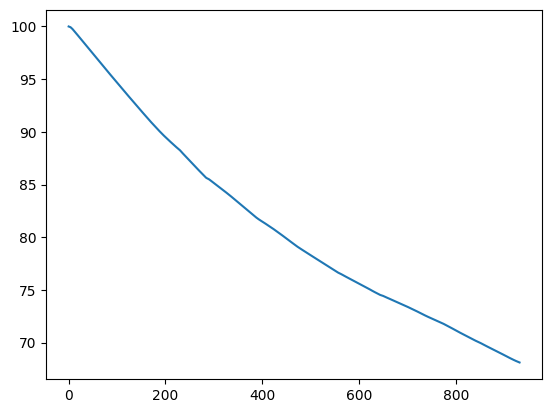

In [17]:
basil_sensor_data['overall_health'].plot(kind='line')

In [18]:
basil_sensor_data['overall_health']

0      100.000000
1       99.981530
2       99.963062
3       99.945046
4       99.926581
          ...    
928     68.183303
929     68.164010
930     68.144692
931     68.125279
932     68.106054
Name: overall_health, Length: 933, dtype: float64

In [19]:
basil_sensor_data

,timestamp,temperature,humidity,soil_raw,soil_moisture,hrs_min_sec,hrs,health_based_on_photos,rel_temp_day_diff_from_opt,rel_hum_diff_from_opt,rel_soil_moisture_diff_from_opt,health_based_on_opt,overall_health
0,2026-03-02 22:49:31,25.0,60.0,1674,93,22:49:31,22,good,0.056604,0.200,0.328571,moderate,100.000000
1,2026-03-02 22:50:37,25.0,60.0,1676,93,22:50:37,22,good,0.056604,0.200,0.328571,moderate,99.981530
2,2026-03-02 22:51:42,25.0,60.0,1674,93,22:51:42,22,good,0.056604,0.200,0.328571,moderate,99.963062
3,2026-03-02 22:52:48,25.0,60.0,1687,92,22:52:48,22,good,0.056604,0.200,0.314286,moderate,99.945046
4,2026-03-02 22:53:52,25.0,60.0,1667,93,22:53:52,22,good,0.056604,0.200,0.328571,moderate,99.926581
...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,2026-03-14 19:55:42,18.8,82.2,2026,79,19:55:42,19,critical,0.290566,0.644,0.128571,critical,68.183303
929,2026-03-14 19:58:31,19.0,83.5,2025,79,19:58:31,19,critical,0.283019,0.670,0.128571,critical,68.164010
930,2026-03-14 19:58:44,19.0,83.6,2022,79,19:58:44,19,critical,0.283019,0.672,0.128571,critical,68.144692
931,2026-03-14 19:59:21,19.0,83.9,2023,79,19:59:21,19,critical,0.283019,0.678,0.128571,critical,68.125279


In [20]:
# mask_night = basil_sensor_data['day_night'] == 'night'
# basil_sensor_data['rel_temp_night_diff_from_opt_ext'] = 0

# temp_less_night = mask_night & (basil_sensor_data['temperature'] < basil_min_temp_night_opt)
# temp_greater_night = mask_night & (basil_sensor_data['temperature'] > basil_max_temp_night_opt)

# basil_sensor_data.loc[temp_less_night, 'rel_temp_night_diff_from_opt_ext'] = (
#     (basil_min_temp_night_opt - basil_sensor_data.loc[temp_less_night, 'temperature'])
#     / basil_min_temp_night_opt
# ).abs()

# basil_sensor_data.loc[temp_greater_night, 'rel_temp_night_diff_from_opt_ext'] = (
#     (basil_sensor_data.loc[temp_greater_night, 'temperature'] - basil_max_temp_night_opt)
#     / basil_max_temp_night_opt
# ).abs()

In [21]:
# mask_day = basil_sensor_data['day_night'] == 'day'
basil_sensor_data['rel_temp_day_diff_from_opt_ext'] = 0

temp_less_day = (basil_sensor_data['temperature'] < basil_min_temp_day_opt)
temp_greater_day =(basil_sensor_data['temperature'] > basil_max_temp_day_opt)

basil_sensor_data.loc[temp_less_day, 'rel_temp_day_diff_from_opt_ext'] = (
    (basil_min_temp_day_opt - basil_sensor_data.loc[temp_less_day, 'temperature'])
    / basil_min_temp_day_opt
).abs()

basil_sensor_data.loc[temp_greater_day, 'rel_temp_day_diff_from_opt_ext'] = (
    (basil_sensor_data.loc[temp_greater_day, 'temperature'] - basil_max_temp_day_opt)
    / basil_max_temp_day_opt
).abs()

C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\3041427471.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00952381 0.00952381 0.00952381 0.03809524 0.06666667 0.08095238
 0.09047619 0.1047619  0.11428571 0.12380952 0.13333333 0.14285714
 0.15238095 0.16190476 0.17142857 0.17619048 0.18095238 0.18571429
 0.19047619 0.19047619 0.19047619 0.19047619 0.1952381  0.1952381
 0.1952381  0.1952381  0.1952381  0.1952381  0.1952381  0.1952381
 0.1952381  0.1952381  0.1952381  0.1952381  0.1952381  0.1952381
 0.1952381  0.1952381  0.1952381  0.1952381  0.1952381  0.1952381
 0.1952381  0.1952381  0.1952381  0.1952381  0.1952381  0.1952381
 0.1952381  0.1952381  0.1952381  0.1952381  0.1952381  0.19047619
 0.19047619 0.1952381  0.19047619 0.1952381  0.19047619 0.1952381
 0.19047619 0.19047619 0.1952381  0.19047619 0.19047619 0.19047619
 0.19047619 0.19047619 0.19047619 0.19047619 0.19047619 0.1904761

In [22]:
basil_sensor_data['rel_hum_diff_from_opt_ext'] = 0
hum_less = basil_sensor_data['humidity'] < basil_min_hum_opt
hum_greater = basil_sensor_data['humidity'] > basil_max_hum_opt


basil_sensor_data.loc[hum_less, 'rel_hum_diff_from_opt_ext'] = (
    (basil_min_hum_opt - basil_sensor_data.loc[hum_less, 'humidity'])
    / basil_min_hum_opt
).abs()

basil_sensor_data.loc[hum_greater, 'rel_hum_diff_from_opt_ext'] = (
    (basil_sensor_data.loc[hum_greater, 'humidity'] - basil_max_hum_opt)
    / basil_max_hum_opt
).abs()

C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\3084242368.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.47833333 0.47333333 0.46833333 0.53666667 0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665      0.665
 0.665      0.665      0.665      0.665      0.665 

In [23]:
basil_sensor_data['rel_soil_moisture_diff_from_opt_ext'] = 0
soil_less = basil_sensor_data['soil_moisture'] < basil_min_soil_moisture_opt
soil_greater = basil_sensor_data['soil_moisture'] > basil_max_soil_moisture_opt

basil_sensor_data.loc[soil_less, 'rel_soil_moisture_diff_from_opt_ext'] = (
    (basil_min_soil_moisture_opt - basil_sensor_data.loc[soil_less, 'soil_moisture'])
    / basil_min_soil_moisture_opt
).abs()

basil_sensor_data.loc[soil_greater, 'rel_soil_moisture_diff_from_opt_ext'] = (
    (basil_sensor_data.loc[soil_greater, 'soil_moisture'] - basil_max_soil_moisture_opt)
    / basil_max_soil_moisture_opt
).abs()

C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\2341603040.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.3        0.13333333 0.25       0.33333333 0.51666667 0.63333333
 0.51666667 0.15      ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  basil_sensor_data.loc[soil_less, 'rel_soil_moisture_diff_from_opt_ext'] = (


In [24]:
basil_sensor_data.head()

,timestamp,temperature,humidity,soil_raw,soil_moisture,hrs_min_sec,hrs,health_based_on_photos,rel_temp_day_diff_from_opt,rel_hum_diff_from_opt,rel_soil_moisture_diff_from_opt,health_based_on_opt,overall_health,rel_temp_day_diff_from_opt_ext,rel_hum_diff_from_opt_ext,rel_soil_moisture_diff_from_opt_ext
0,2026-03-02 22:49:31,25.0,60.0,1674,93,22:49:31,22,good,0.056604,0.2,0.328571,moderate,100.000000,0.0,0.0,0.1625
1,2026-03-02 22:50:37,25.0,60.0,1676,93,22:50:37,22,good,0.056604,0.2,0.328571,moderate,99.981530,0.0,0.0,0.1625
2,2026-03-02 22:51:42,25.0,60.0,1674,93,22:51:42,22,good,0.056604,0.2,0.328571,moderate,99.963062,0.0,0.0,0.1625
3,2026-03-02 22:52:48,25.0,60.0,1687,92,22:52:48,22,good,0.056604,0.2,0.314286,moderate,99.945046,0.0,0.0,0.1500
4,2026-03-02 22:53:52,25.0,60.0,1667,93,22:53:52,22,good,0.056604,0.2,0.328571,moderate,99.926581,0.0,0.0,0.1625


In [25]:
basil_sensor_data['overall_health_on_ext'] = 100
for i in range(1, len(basil_sensor_data)):
    prev = basil_sensor_data.loc[i-1, 'overall_health_on_ext']

    hum = basil_sensor_data.loc[i, 'rel_hum_diff_from_opt_ext']
    soil = basil_sensor_data.loc[i, 'rel_soil_moisture_diff_from_opt_ext']

    # if basil_sensor_data.loc[i, 'day_night'] == 'day':
    temp = basil_sensor_data.loc[i, 'rel_temp_day_diff_from_opt_ext']
    # else:
    #     temp = basil_sensor_data.loc[i, 'rel_temp_night_diff_from_opt_ext']

    # normalized penalty (0–1 range ideally)
    penalty = (hum + soil + temp) /3

    
   

    health_factor = 1 / (1 + np.exp(-(prev - 75)/10))
    decay = penalty * (0.1 + 0.9 * health_factor)
    

    if basil_sensor_data.loc[i, 'health_based_on_opt'] == 'good':
        recovery = (1 - prev/100) * health_factor
        new_health = prev + recovery   # slow recovery
    else:
        new_health = prev - decay

    # clamp between 0 and 100
    basil_sensor_data.loc[i, 'overall_health_on_ext'] = max(0, min(100, new_health))



C:\Users\SARUP HUSSAIN\AppData\Local\Temp\ipykernel_28344\2695911229.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.94953141960937' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  basil_sensor_data.loc[i, 'overall_health_on_ext'] = max(0, min(100, new_health))


<Axes: >

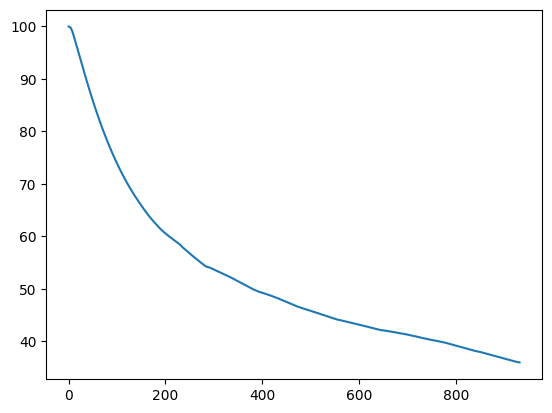

In [26]:
basil_sensor_data['overall_health_on_ext'].plot(kind='line')

# LSTM

In [1637]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score


# =====================================================
# 1. HEALTH SCORE (SMOOTH + STABLE BASELINE)
# =====================================================
def create_health_score(df):
    df = df.copy()

    df["health_score"] = df["overall_health_on_ext"].ewm(span=7).mean()

    df["health_score"] = (
        df["health_score"] - df["health_score"].min()
    ) / (df["health_score"].max() - df["health_score"].min() + 1e-8)

    return df


# =====================================================
# 2. PHASE LABELING (CRITICAL FOR THE CURRENT DISTRIBUTION)
# =====================================================
def create_phase_labels(df):
    """
    Learns lifecycle structure:
    early (mostly healthy), mid, late degradation
    """

    q1 = df["health_score"].quantile(0.7)
    q2 = df["health_score"].quantile(0.4)

    def label(x):
        if x >= q1:
            return 2  # healthy phase
        elif x >= q2:
            return 1  # transition phase
        else:
            return 0  # stress phase

    df["phase"] = df["health_score"].apply(label)
    return df


# =====================================================
# 3. FEATURES
# =====================================================
def add_features(df):
    df = df.copy()

    df["temp_change"] = df["temperature"].diff().fillna(0)
    df["humidity_change"] = df["humidity"].diff().fillna(0)
    df["soil_change"] = df["soil_moisture"].diff().fillna(0)

    df["health_lag_1"] = df["health_score"].shift(1).bfill()
    df["health_ma_3"] = df["health_score"].rolling(3).mean().bfill()
    df["health_trend"] = df["health_score"].diff().fillna(0)

    return df


# =====================================================
# 4. FEATURES
# =====================================================
SENSOR_COLS = [
    "temperature",
    "humidity",
    "soil_moisture",
    "temp_change",
    "humidity_change",
    "soil_change"
]

HEALTH_COLS = [
    "health_score",
    "health_lag_1",
    "health_ma_3",
    "health_trend"
]


# =====================================================
# 5. SEQUENCES (MULTI-TASK OUTPUT)
# =====================================================
def create_sequences(df, window=25):

    Xs, Xh, y_reg, y_cls = [], [], [], []

    sensor = df[SENSOR_COLS].values
    health = df[HEALTH_COLS].values

    target_reg = df["health_score"].shift(-1).fillna(df["health_score"]).values
    target_cls = df["phase"].values

    for i in range(window, len(df)):
        Xs.append(sensor[i-window:i])
        Xh.append(health[i-window:i])

        y_reg.append(target_reg[i])
        y_cls.append(target_cls[i])

    return np.array(Xs), np.array(Xh), np.array(y_reg), np.array(y_cls)


# =====================================================
# 6. DATASET
# =====================================================
class PlantDataset(Dataset):
    def __init__(self, Xs, Xh, y_reg, y_cls):
        self.Xs = torch.tensor(Xs, dtype=torch.float32)
        self.Xh = torch.tensor(Xh, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.long)

    def __len__(self):
        return len(self.y_reg)

    def __getitem__(self, idx):
        return self.Xs[idx], self.Xh[idx], self.y_reg[idx], self.y_cls[idx]


# =====================================================
# 7. MULTI-TASK MODEL
# =====================================================
class TFGRU(nn.Module):
    def __init__(self, sensor_dim, health_dim, hidden=64):
        super().__init__()

        self.sensor_gru = nn.GRU(sensor_dim, hidden, batch_first=True)
        self.health_gru = nn.GRU(health_dim, hidden, batch_first=True)

        self.shared = nn.Linear(hidden * 2, hidden)

        # regression head (future health)
        self.reg_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # classification head (phase)
        self.cls_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x_sensor, x_health):

        s_out, _ = self.sensor_gru(x_sensor)
        h_out, _ = self.health_gru(x_health)

        x = torch.cat([s_out[:, -1], h_out[:, -1]], dim=-1)

        x = torch.relu(self.shared(x))

        reg = self.reg_head(x).squeeze()
        cls = self.cls_head(x)

        return reg, cls


# =====================================================
# 8. TRAINING
# =====================================================
def run_training(df, window=25, batch_size=32, epochs=40):

    df = create_health_score(df)
    df = create_phase_labels(df)
    df = add_features(df)
    df = df.sort_index().reset_index(drop=True)

    Xs, Xh, y_reg, y_cls = create_sequences(df, window)

    split = int(len(Xs) * 0.8)

    Xs_train, Xs_test = Xs[:split], Xs[split:]
    Xh_train, Xh_test = Xh[:split], Xh[split:]
    y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]
    y_cls_train, y_cls_test = y_cls[:split], y_cls[split:]

    scaler_s = StandardScaler()
    scaler_h = StandardScaler()

    Xs_train = scaler_s.fit_transform(
        Xs_train.reshape(-1, Xs_train.shape[-1])
    ).reshape(Xs_train.shape)

    Xs_test = scaler_s.transform(
        Xs_test.reshape(-1, Xs_test.shape[-1])
    ).reshape(Xs_test.shape)

    Xh_train = scaler_h.fit_transform(
        Xh_train.reshape(-1, Xh_train.shape[-1])
    ).reshape(Xh_train.shape)

    Xh_test = scaler_h.transform(
        Xh_test.reshape(-1, Xh_test.shape[-1])
    ).reshape(Xh_test.shape)

    train_loader = DataLoader(
        PlantDataset(Xs_train, Xh_train, y_reg_train, y_cls_train),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        PlantDataset(Xs_test, Xh_test, y_reg_test, y_cls_test),
        batch_size=batch_size,
        shuffle=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = TFGRU(
        sensor_dim=len(SENSOR_COLS),
        health_dim=len(HEALTH_COLS)
    ).to(device)

    reg_loss_fn = nn.MSELoss()
    cls_loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # =================================================
    # TRAIN LOOP
    # =================================================
    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for xb_s, xb_h, y_reg, y_cls in train_loader:
            xb_s, xb_h = xb_s.to(device), xb_h.to(device)
            y_reg, y_cls = y_reg.to(device), y_cls.to(device)

            optimizer.zero_grad()

            reg_out, cls_out = model(xb_s, xb_h)

            loss = (
                reg_loss_fn(reg_out, y_reg) +
                0.5 * cls_loss_fn(cls_out, y_cls)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # =================================================
        # EVALUATION
        # =================================================
        model.eval()

        preds_reg, true_reg = [], []
        preds_cls, true_cls = [], []

        with torch.no_grad():
            for xb_s, xb_h, y_reg, y_cls in test_loader:
                xb_s, xb_h = xb_s.to(device), xb_h.to(device)

                reg_out, cls_out = model(xb_s, xb_h)

                preds_reg.extend(reg_out.cpu().numpy())
                true_reg.extend(y_reg.numpy())

                preds_cls.extend(torch.argmax(cls_out, dim=1).cpu().numpy())
                true_cls.extend(y_cls.numpy())

        rmse = np.sqrt(mean_squared_error(true_reg, preds_reg))
        mae = mean_absolute_error(true_reg, preds_reg)
        acc = accuracy_score(true_cls, preds_cls)

        print(
            f"Epoch {epoch+1} | "
            f"Loss {total_loss:.4f} | "
            f"RMSE {rmse:.5f} | "
            f"MAE {mae:.5f} | "
            f"PhaseAcc {acc:.4f}"
        )

    return model, scaler_s, scaler_h

In [1638]:
if __name__ == "__main__":

    model, scaler_s, scaler_h = run_training(
        df=basil_sensor_data,
        window=25,
        batch_size=32,
        epochs=30
    )

    # -----------------------------
    # Save model
    # -----------------------------
    torch.save(model.state_dict(), "tfgru_model.pth")

    # -----------------------------
    # Save scalers
    # -----------------------------
    import joblib

    joblib.dump(scaler_s, "sensor_scaler.pkl")
    joblib.dump(scaler_h, "health_scaler.pkl")

    print("Training complete. Model and scalers saved.")

Epoch 1 | Loss 11.6041 | RMSE 0.06672 | MAE 0.06342 | PhaseAcc 1.0000
Epoch 2 | Loss 5.9491 | RMSE 0.03494 | MAE 0.02659 | PhaseAcc 0.6264
Epoch 3 | Loss 1.5585 | RMSE 0.02202 | MAE 0.01883 | PhaseAcc 1.0000
Epoch 4 | Loss 0.6467 | RMSE 0.05705 | MAE 0.05518 | PhaseAcc 1.0000
Epoch 5 | Loss 0.4187 | RMSE 0.04271 | MAE 0.04065 | PhaseAcc 1.0000
Epoch 6 | Loss 0.3303 | RMSE 0.03677 | MAE 0.03494 | PhaseAcc 1.0000
Epoch 7 | Loss 0.2975 | RMSE 0.03182 | MAE 0.02950 | PhaseAcc 1.0000
Epoch 8 | Loss 0.1020 | RMSE 0.02540 | MAE 0.02286 | PhaseAcc 1.0000
Epoch 9 | Loss 0.1906 | RMSE 0.02424 | MAE 0.02154 | PhaseAcc 1.0000
Epoch 10 | Loss 0.3072 | RMSE 0.04024 | MAE 0.03856 | PhaseAcc 1.0000
Epoch 11 | Loss 0.1493 | RMSE 0.01116 | MAE 0.00968 | PhaseAcc 1.0000
Epoch 12 | Loss 0.1107 | RMSE 0.03187 | MAE 0.02989 | PhaseAcc 1.0000
Epoch 13 | Loss 0.1512 | RMSE 0.03568 | MAE 0.03401 | PhaseAcc 1.0000
Epoch 14 | Loss 0.2290 | RMSE 0.01160 | MAE 0.00940 | PhaseAcc 1.0000
Epoch 15 | Loss 0.1120 | RMS

#

In [1639]:

import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score


# =====================================================
# 1. HEALTH SCORE
# =====================================================
def create_health_score(df):
    df = df.copy()

    df["health_score"] = df["overall_health_on_ext"].ewm(span=7).mean()

    df["health_score"] = (
        df["health_score"] - df["health_score"].min()
    ) / (df["health_score"].max() - df["health_score"].min() + 1e-8)

    return df


# =====================================================
# 2. TARGETS (CAUSAL)
# =====================================================
def create_targets(df, horizon=3):
    df = df.copy()

    # future health (smooth target)
    df["future_health"] = df["health_score"].shift(-horizon)

    future_drop = df["health_score"] - df["health_score"].shift(-5)

    threshold = future_drop.quantile(0.5)  # top 30% drops

    df["hazard"] = (
        df["health_score"].shift(-3) < df["health_score"] - threshold
    ).astype(int)

    df = df.dropna().reset_index(drop=True)

    return df


# =====================================================
# 3. FEATURES
# =====================================================
def add_features(df):
    df = df.copy()

    df["temp_change"] = df["temperature"].diff().fillna(0)
    df["humidity_change"] = df["humidity"].diff().fillna(0)
    df["soil_change"] = df["soil_moisture"].diff().fillna(0)

    df["health_lag_1"] = df["health_score"].shift(1).bfill()
    df["health_ma_3"] = df["health_score"].rolling(3).mean().bfill()
    df["health_trend"] = df["health_score"].diff().fillna(0)

    return df


# =====================================================
# 4. FEATURE COLUMNS
# =====================================================
SENSOR_COLS = [
    "temperature",
    "humidity",
    "soil_moisture",
    "temp_change",
    "humidity_change",
    "soil_change"
]

HEALTH_COLS = [
    "health_score",
    "health_lag_1",
    "health_ma_3",
    "health_trend"
]


# =====================================================
# 5. SEQUENCE CREATION
# =====================================================
def create_sequences(df, window=25):

    Xs, Xh, y_reg, y_hazard = [], [], [], []

    sensor = df[SENSOR_COLS].values
    health = df[HEALTH_COLS].values

    target_reg = df["future_health"].values
    target_hazard = df["hazard"].values

    for i in range(window, len(df)):
        Xs.append(sensor[i-window:i])
        Xh.append(health[i-window:i])

        y_reg.append(target_reg[i])
        y_hazard.append(target_hazard[i])

    return (
        np.array(Xs),
        np.array(Xh),
        np.array(y_reg),
        np.array(y_hazard)
    )


# =====================================================
# 6. DATASET
# =====================================================
class PlantDataset(Dataset):
    def __init__(self, Xs, Xh, y_reg, y_hazard):
        self.Xs = torch.tensor(Xs, dtype=torch.float32)
        self.Xh = torch.tensor(Xh, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_hazard = torch.tensor(y_hazard, dtype=torch.float32)

    def __len__(self):
        return len(self.y_reg)

    def __getitem__(self, idx):
        return (
            self.Xs[idx],
            self.Xh[idx],
            self.y_reg[idx],
            self.y_hazard[idx]
        )


# =====================================================
# 7. MODEL (V5)
# =====================================================
class PlantV5(nn.Module):
    def __init__(self, sensor_dim, health_dim, hidden=64):
        super().__init__()

        self.sensor_gru = nn.GRU(sensor_dim, hidden, batch_first=True)
        self.health_gru = nn.GRU(health_dim, hidden, batch_first=True)

        self.fusion = nn.Linear(hidden * 2, hidden)

        # future health
        self.reg_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        # degradation probability
        self.hazard_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, xs, xh):

        s_out, _ = self.sensor_gru(xs)
        h_out, _ = self.health_gru(xh)

        x = torch.cat([s_out[:, -1], h_out[:, -1]], dim=-1)

        latent = torch.relu(self.fusion(x))

        future_health = self.reg_head(latent).squeeze()
        hazard = torch.sigmoid(self.hazard_head(latent)).squeeze()

        return future_health, hazard


# =====================================================
# 8. TRAINING
# =====================================================
def run_training(df, window=25, batch_size=32, epochs=40):

    df = create_health_score(df)
    df = add_features(df)
    df = create_targets(df)

    Xs, Xh, y_reg, y_hazard = create_sequences(df, window)

    split = int(len(Xs) * 0.7)

    Xs_train, Xs_test = Xs[:split], Xs[split:]
    Xh_train, Xh_test = Xh[:split], Xh[split:]
    y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]
    y_hazard_train, y_hazard_test = y_hazard[:split], y_hazard[split:]

    # scaling
    scaler_s = StandardScaler()
    scaler_h = StandardScaler()

    Xs_train = scaler_s.fit_transform(
        Xs_train.reshape(-1, Xs_train.shape[-1])
    ).reshape(Xs_train.shape)

    Xs_test = scaler_s.transform(
        Xs_test.reshape(-1, Xs_test.shape[-1])
    ).reshape(Xs_test.shape)

    Xh_train = scaler_h.fit_transform(
        Xh_train.reshape(-1, Xh_train.shape[-1])
    ).reshape(Xh_train.shape)

    Xh_test = scaler_h.transform(
        Xh_test.reshape(-1, Xh_test.shape[-1])
    ).reshape(Xh_test.shape)

    # loaders
    train_loader = DataLoader(
        PlantDataset(Xs_train, Xh_train, y_reg_train, y_hazard_train),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        PlantDataset(Xs_test, Xh_test, y_reg_test, y_hazard_test),
        batch_size=batch_size,
        shuffle=False
    )

    # device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PlantV5(
        sensor_dim=len(SENSOR_COLS),
        health_dim=len(HEALTH_COLS)
    ).to(device)

    reg_loss_fn = nn.MSELoss()
    hazard_loss_fn = nn.BCELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_loss = float("inf")

    # =================================================
    # TRAIN LOOP
    # =================================================
    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for xb_s, xb_h, yb_reg, yb_haz in train_loader:
            xb_s, xb_h = xb_s.to(device), xb_h.to(device)
            yb_reg, yb_haz = yb_reg.to(device), yb_haz.to(device)

            optimizer.zero_grad()

            pred_reg, pred_haz = model(xb_s, xb_h)

            loss = (
                reg_loss_fn(pred_reg, yb_reg) +
                0.3 * hazard_loss_fn(pred_haz, yb_haz)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # =================================================
        # EVALUATION
        # =================================================
        model.eval()

        pr, tr = [], []
        ph, th = [], []

        with torch.no_grad():
            for xb_s, xb_h, yb_reg, yb_haz in test_loader:
                xb_s, xb_h = xb_s.to(device), xb_h.to(device)

                out_reg, out_haz = model(xb_s, xb_h)

                pr.extend(out_reg.cpu().numpy())
                tr.extend(yb_reg.numpy())

                ph.extend((out_haz.cpu().numpy() > 0.5).astype(int))
                th.extend(yb_haz.numpy())

        pr, tr = np.array(pr), np.array(tr)

        rmse = np.sqrt(mean_squared_error(tr, pr))
        mae = mean_absolute_error(tr, pr)
        acc = accuracy_score(th, ph)

        print(
            f"Epoch {epoch+1} | "
            f"Loss {total_loss:.4f} | "
            f"RMSE {rmse:.5f} | "
            f"MAE {mae:.5f} | "
            f"HazardAcc {acc:.4f}"
        )

    return model, scaler_s, scaler_h


# =====================================================
# 9. RUN
# =====================================================
if __name__ == "__main__":

    model, scaler_s, scaler_h = run_training(
        df=basil_sensor_data,
        window=15,
        batch_size=32,
        epochs=30
    )

    torch.save(model.state_dict(), "plant_v5_model.pth")

    import joblib
    joblib.dump(scaler_s, "scaler_sensor.pkl")
    joblib.dump(scaler_h, "scaler_health.pkl")

    print("Training complete. Model saved.")

Epoch 1 | Loss 5.5843 | RMSE 0.21468 | MAE 0.21229 | HazardAcc 1.0000
Epoch 2 | Loss 2.8960 | RMSE 0.12383 | MAE 0.12122 | HazardAcc 1.0000
Epoch 3 | Loss 0.7997 | RMSE 0.05878 | MAE 0.05015 | HazardAcc 1.0000
Epoch 4 | Loss 0.1140 | RMSE 0.04790 | MAE 0.03927 | HazardAcc 1.0000
Epoch 5 | Loss 0.0599 | RMSE 0.05452 | MAE 0.04492 | HazardAcc 1.0000
Epoch 6 | Loss 0.0688 | RMSE 0.05932 | MAE 0.05510 | HazardAcc 1.0000
Epoch 7 | Loss 0.0522 | RMSE 0.03389 | MAE 0.02898 | HazardAcc 1.0000
Epoch 8 | Loss 0.0351 | RMSE 0.04231 | MAE 0.03558 | HazardAcc 1.0000
Epoch 9 | Loss 0.0533 | RMSE 0.04205 | MAE 0.03619 | HazardAcc 1.0000
Epoch 10 | Loss 0.0438 | RMSE 0.03152 | MAE 0.02502 | HazardAcc 1.0000
Epoch 11 | Loss 0.0501 | RMSE 0.03161 | MAE 0.02543 | HazardAcc 1.0000
Epoch 12 | Loss 0.0378 | RMSE 0.03450 | MAE 0.02864 | HazardAcc 1.0000
Epoch 13 | Loss 0.0255 | RMSE 0.02842 | MAE 0.02352 | HazardAcc 1.0000
Epoch 14 | Loss 0.0462 | RMSE 0.03156 | MAE 0.02702 | HazardAcc 1.0000
Epoch 15 | Loss

In [1640]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =====================================================
# 1. HEALTH SCORE
# =====================================================
def create_health_score(df):
    df = df.copy()

    df["health_score"] = df["overall_health_on_ext"].ewm(span=7).mean()

    df["health_score"] = (
        df["health_score"] - df["health_score"].min()
    ) / (df["health_score"].max() - df["health_score"].min() + 1e-8)

    return df


# =====================================================
# 2. TARGETS (CONTINUOUS RISK)
# =====================================================
def create_targets(df, horizon=5):
    df = df.copy()

    df["future_health"] = df["health_score"].shift(-horizon)

    # risk = how much health drops
    df["risk"] = (
        df["health_score"] - df["future_health"]
    ).clip(lower=0)

    df = df.dropna().reset_index(drop=True)

    return df


# =====================================================
# 3. FEATURES
# =====================================================
def add_features(df):
    df = df.copy()

    df["temp_change"] = df["temperature"].diff().fillna(0)
    df["humidity_change"] = df["humidity"].diff().fillna(0)
    df["soil_change"] = df["soil_moisture"].diff().fillna(0)

    df["health_lag_1"] = df["health_score"].shift(1).bfill()
    df["health_ma_3"] = df["health_score"].rolling(3).mean().bfill()
    df["health_trend"] = df["health_score"].diff().fillna(0)

    return df


# =====================================================
# 4. FEATURES
# =====================================================
SENSOR_COLS = [
    "temperature",
    "humidity",
    "soil_moisture",
    "temp_change",
    "humidity_change",
    "soil_change"
]

HEALTH_COLS = [
    "health_score",
    "health_lag_1",
    "health_ma_3",
    "health_trend"
]


# =====================================================
# 5. SEQUENCES
# =====================================================
def create_sequences(df, window=25):

    Xs, Xh, y_reg, y_risk = [], [], [], []

    sensor = df[SENSOR_COLS].values
    health = df[HEALTH_COLS].values

    future = df["future_health"].values
    risk = df["risk"].values

    for i in range(window, len(df)):
        Xs.append(sensor[i-window:i])
        Xh.append(health[i-window:i])

        y_reg.append(future[i])
        y_risk.append(risk[i])

    return (
        np.array(Xs),
        np.array(Xh),
        np.array(y_reg),
        np.array(y_risk)
    )


# =====================================================
# 6. DATASET
# =====================================================
class PlantDataset(Dataset):
    def __init__(self, Xs, Xh, y_reg, y_risk):
        self.Xs = torch.tensor(Xs, dtype=torch.float32)
        self.Xh = torch.tensor(Xh, dtype=torch.float32)
        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_risk = torch.tensor(y_risk, dtype=torch.float32)

    def __len__(self):
        return len(self.y_reg)

    def __getitem__(self, idx):
        return (
            self.Xs[idx],
            self.Xh[idx],
            self.y_reg[idx],
            self.y_risk[idx]
        )


# =====================================================
# 7. MODEL
# =====================================================
class PlantV51(nn.Module):
    def __init__(self, sensor_dim, health_dim, hidden=64):
        super().__init__()

        self.sensor_gru = nn.GRU(sensor_dim, hidden, batch_first=True)
        self.health_gru = nn.GRU(health_dim, hidden, batch_first=True)

        self.fusion = nn.Linear(hidden * 2, hidden)

        self.reg_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        self.risk_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, xs, xh):

        s_out, _ = self.sensor_gru(xs)
        h_out, _ = self.health_gru(xh)

        x = torch.cat([s_out[:, -1], h_out[:, -1]], dim=-1)

        latent = torch.relu(self.fusion(x))

        future = self.reg_head(latent).squeeze()
        risk = self.risk_head(latent).squeeze()

        return future, risk


# =====================================================
# 8. TRAINING
# =====================================================
def run_training(df, window=25, batch_size=32, epochs=40):

    df = create_health_score(df)
    df = add_features(df)
    df = create_targets(df)

    Xs, Xh, y_reg, y_risk = create_sequences(df, window)

    split = int(len(Xs) * 0.7)

    Xs_train, Xs_test = Xs[:split], Xs[split:]
    Xh_train, Xh_test = Xh[:split], Xh[split:]
    y_reg_train, y_reg_test = y_reg[:split], y_reg[split:]
    y_risk_train, y_risk_test = y_risk[:split], y_risk[split:]

    scaler_s = StandardScaler()
    scaler_h = StandardScaler()

    Xs_train = scaler_s.fit_transform(
        Xs_train.reshape(-1, Xs_train.shape[-1])
    ).reshape(Xs_train.shape)

    Xs_test = scaler_s.transform(
        Xs_test.reshape(-1, Xs_test.shape[-1])
    ).reshape(Xs_test.shape)

    Xh_train = scaler_h.fit_transform(
        Xh_train.reshape(-1, Xh_train.shape[-1])
    ).reshape(Xh_train.shape)

    Xh_test = scaler_h.transform(
        Xh_test.reshape(-1, Xh_test.shape[-1])
    ).reshape(Xh_test.shape)

    train_loader = DataLoader(
        PlantDataset(Xs_train, Xh_train, y_reg_train, y_risk_train),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        PlantDataset(Xs_test, Xh_test, y_reg_test, y_risk_test),
        batch_size=batch_size,
        shuffle=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PlantV51(
        sensor_dim=len(SENSOR_COLS),
        health_dim=len(HEALTH_COLS)
    ).to(device)

    reg_loss_fn = nn.MSELoss()
    risk_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # =================================================
    # TRAIN LOOP
    # =================================================
    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for xb_s, xb_h, yb_reg, yb_risk in train_loader:
            xb_s, xb_h = xb_s.to(device), xb_h.to(device)
            yb_reg, yb_risk = yb_reg.to(device), yb_risk.to(device)

            optimizer.zero_grad()

            pred_reg, pred_risk = model(xb_s, xb_h)

            loss = (
                reg_loss_fn(pred_reg, yb_reg) +
                0.5 * risk_loss_fn(pred_risk, yb_risk)
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # evaluation
        model.eval()

        pr, tr = [], []
        prisk, trisk = [], []

        with torch.no_grad():
            for xb_s, xb_h, yb_reg, yb_risk in test_loader:
                xb_s, xb_h = xb_s.to(device), xb_h.to(device)

                out_reg, out_risk = model(xb_s, xb_h)

                pr.extend(out_reg.cpu().numpy())
                tr.extend(yb_reg.numpy())

                prisk.extend(out_risk.cpu().numpy())
                trisk.extend(yb_risk.numpy())

        rmse = np.sqrt(mean_squared_error(tr, pr))
        mae = mean_absolute_error(tr, pr)
        risk_mae = mean_absolute_error(trisk, prisk)

        print(
            f"Epoch {epoch+1} | "
            f"Loss {total_loss:.4f} | "
            f"RMSE {rmse:.5f} | "
            f"MAE {mae:.5f} | "
            f"RiskMAE {risk_mae:.5f}"
        )

    return model, scaler_s, scaler_h

In [1641]:
# =====================================================
# 9. RUN
# =====================================================
if __name__ == "__main__":

    model, scaler_s, scaler_h = run_training(
        df=basil_sensor_data,
        window=15,
        batch_size=32,
        epochs=30
    )

    torch.save(model.state_dict(), "plant_v5_1_model.pth")

    import joblib
    joblib.dump(scaler_s, "scaler_sensor.pkl")
    joblib.dump(scaler_h, "scaler_health.pkl")

    print("Training complete. Model saved.")

Epoch 1 | Loss 2.9354 | RMSE 0.12230 | MAE 0.11427 | RiskMAE 0.38518
Epoch 2 | Loss 0.7868 | RMSE 0.08539 | MAE 0.07753 | RiskMAE 0.09980
Epoch 3 | Loss 0.0434 | RMSE 0.06091 | MAE 0.05743 | RiskMAE 0.00165
Epoch 4 | Loss 0.0059 | RMSE 0.04892 | MAE 0.04410 | RiskMAE 0.00035
Epoch 5 | Loss 0.0027 | RMSE 0.04327 | MAE 0.03852 | RiskMAE 0.00034
Epoch 6 | Loss 0.0013 | RMSE 0.03743 | MAE 0.03221 | RiskMAE 0.00036
Epoch 7 | Loss 0.0012 | RMSE 0.03835 | MAE 0.03387 | RiskMAE 0.00036
Epoch 8 | Loss 0.0008 | RMSE 0.03389 | MAE 0.02927 | RiskMAE 0.00036
Epoch 9 | Loss 0.0007 | RMSE 0.02842 | MAE 0.02322 | RiskMAE 0.00039
Epoch 10 | Loss 0.0006 | RMSE 0.02932 | MAE 0.02502 | RiskMAE 0.00039
Epoch 11 | Loss 0.0005 | RMSE 0.02730 | MAE 0.02341 | RiskMAE 0.00041
Epoch 12 | Loss 0.0004 | RMSE 0.02496 | MAE 0.02108 | RiskMAE 0.00044
Epoch 13 | Loss 0.0004 | RMSE 0.02585 | MAE 0.02260 | RiskMAE 0.00048
Epoch 14 | Loss 0.0003 | RMSE 0.02166 | MAE 0.01762 | RiskMAE 0.00052
Epoch 15 | Loss 0.0003 | RMSE

In [31]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib


# =====================================================
# 1. TARGET ENGINEERING (V6 FIXED)
# =====================================================
def create_health_targets(df):
    df = df.copy()

    # smoothed health
    df["health_score"] = df["overall_health_on_ext"].ewm(span=5).mean()

    # normalize 0–1
    df["health_score"] = (
        df["health_score"] - df["health_score"].min()
    ) / (df["health_score"].max() - df["health_score"].min() + 1e-8)

    df["health_velocity"] = df["health_score"].diff().fillna(0)
    df["health_acceleration"] = df["health_velocity"].diff().fillna(0)

    horizon = 5

    df["future_health"] = df["health_score"].shift(-horizon)
    df["future_velocity"] = df["health_velocity"].shift(-horizon)
    df["future_acceleration"] = df["health_acceleration"].shift(-horizon)

    # stable risk signal (clipped)
    df["risk_score"] = (0.5 * (1 - df["future_health"]) +
    0.3 * abs(df["future_velocity"]) +
    0.2 * abs(df["future_acceleration"]))

    df = df.dropna()

    return df


# =====================================================
# 2. FEATURES
# =====================================================
def add_features(df):
    df = df.copy()

    df["temp_change"] = df["temperature"].diff().fillna(0)
    df["humidity_change"] = df["humidity"].diff().fillna(0)
    df["soil_change"] = df["soil_moisture"].diff().fillna(0)

    return df


SENSOR_COLS = [
    "temperature",
    "humidity",
    "soil_moisture",
    "temp_change",
    "humidity_change",
    "soil_change"
]

STATE_COLS = [
    "health_score",
    "health_velocity",
    "health_acceleration"
]


# =====================================================
# 3. SEQUENCE CREATION
# =====================================================
def create_sequences(df, window=25):

    Xs, Xstate = [], []
    y_health, y_risk = [], []

    sensor = df[SENSOR_COLS].values
    state = df[STATE_COLS].values

    for i in range(window, len(df)):
        Xs.append(sensor[i-window:i])
        Xstate.append(state[i-window:i])

        y_health.append(df["future_health"].iloc[i])
        y_risk.append(df["risk_score"].iloc[i])

    return (
        np.array(Xs),
        np.array(Xstate),
        np.array(y_health),
        np.array(y_risk)
    )


# =====================================================
# 4. DATASET
# =====================================================
class PlantDataset(Dataset):
    def __init__(self, Xs, Xstate, yh, yr):
        self.Xs = torch.tensor(Xs, dtype=torch.float32)
        self.Xstate = torch.tensor(Xstate, dtype=torch.float32)
        self.yh = torch.tensor(yh, dtype=torch.float32)
        self.yr = torch.tensor(yr, dtype=torch.float32)

    def __len__(self):
        return len(self.yh)

    def __getitem__(self, idx):
        return self.Xs[idx], self.Xstate[idx], self.yh[idx], self.yr[idx]


# =====================================================
# 5. MODEL (FIXED OUTPUT RANGE)
# =====================================================
class PlantModelV6(nn.Module):
    def __init__(self, sensor_dim, state_dim, hidden=64):
        super().__init__()

        self.sensor_gru = nn.GRU(sensor_dim, hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.state_gru = nn.GRU(state_dim, hidden, num_layers=2, batch_first=True, dropout=0.2)

        self.attn = nn.Linear(hidden * 2, 1)

        # ✅ FIXED: bounded outputs
        self.health_head = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()   # 0–1
        )

        self.risk_head = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Tanh()      # -1 to 1
        )

    def forward(self, xs, xstate):

        s_out, _ = self.sensor_gru(xs)
        h_out, _ = self.state_gru(xstate)

        x = torch.cat([s_out, h_out], dim=-1)

        attn = torch.softmax(self.attn(x), dim=1)
        context = torch.sum(attn * x, dim=1)

        health = self.health_head(context).squeeze()
        risk = self.risk_head(context).squeeze()

        return health, risk


# =====================================================
# 6. TRAINING
# =====================================================
def run_training(df, window=25, epochs=30, batch_size=32):

    # IMPORTANT: correct order
    df = add_features(df)
    df = create_health_targets(df)

    df = df.sort_index().reset_index(drop=True)

    Xs, Xstate, yh, yr = create_sequences(df, window)

    split = int(len(Xs) * 0.7)

    Xs_tr, Xs_te = Xs[:split], Xs[split:]
    Xst_tr, Xst_te = Xstate[:split], Xstate[split:]
    yh_tr, yh_te = yh[:split], yh[split:]
    yr_tr, yr_te = yr[:split], yr[split:]

    scaler_s = StandardScaler()
    scaler_st = StandardScaler()

    Xs_tr = scaler_s.fit_transform(Xs_tr.reshape(-1, Xs_tr.shape[-1])).reshape(Xs_tr.shape)
    Xs_te = scaler_s.transform(Xs_te.reshape(-1, Xs_te.shape[-1])).reshape(Xs_te.shape)

    Xst_tr = scaler_st.fit_transform(Xst_tr.reshape(-1, Xst_tr.shape[-1])).reshape(Xst_tr.shape)
    Xst_te = scaler_st.transform(Xst_te.reshape(-1, Xst_te.shape[-1])).reshape(Xst_te.shape)

    train_loader = DataLoader(
        PlantDataset(Xs_tr, Xst_tr, yh_tr, yr_tr),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        PlantDataset(Xs_te, Xst_te, yh_te, yr_te),
        batch_size=batch_size,
        shuffle=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PlantModelV6(len(SENSOR_COLS), len(STATE_COLS)).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    loss_h = nn.MSELoss()
    loss_r = nn.HuberLoss()

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for xs, xst, yh_b, yr_b in train_loader:
            xs, xst = xs.to(device), xst.to(device)
            yh_b, yr_b = yh_b.to(device), yr_b.to(device)

            optimizer.zero_grad()

            pred_h, pred_r = model(xs, xst)

            loss = 0.8 * loss_h(pred_h, yh_b) + 1.2 * loss_r(pred_r, yr_b)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # evaluation
        model.eval()
        ph, th, pr, tr = [], [], [], []

        with torch.no_grad():
            for xs, xst, yh_b, yr_b in test_loader:
                xs, xst = xs.to(device), xst.to(device)

                h, r = model(xs, xst)

                ph.extend(h.cpu().numpy())
                th.extend(yh_b.numpy())

                pr.extend(r.cpu().numpy())
                tr.extend(yr_b.numpy())

        ph, th = np.array(ph), np.array(th)
        pr, tr = np.array(pr), np.array(tr)

        rmse = np.sqrt(mean_squared_error(th, ph))
        mae = mean_absolute_error(th, ph)
        risk_mae = mean_absolute_error(tr, pr)

        print(
            f"Epoch {epoch+1} | Loss {total_loss:.4f} | "
            f"RMSE {rmse:.5f} | MAE {mae:.5f} | RiskMAE {risk_mae:.5f}"
        )

    return model, scaler_s, scaler_st


# =====================================================
# 7. EXECUTION
# =====================================================
if __name__ == "__main__":

    df = basil_sensor_data.copy()

    model, scaler_s, scaler_st = run_training(
        df=df,
        window=25,
        epochs=30,
        batch_size=32
    )

    torch.save(model.state_dict(), "plant_model_v6.pth")
    joblib.dump(scaler_s, "scaler_sensor.pkl")
    joblib.dump(scaler_st, "scaler_state.pkl")

    print("✅ Training complete. Model and scalers saved.")

Epoch 1 | Loss 0.8014 | RMSE 0.10994 | MAE 0.10072 | RiskMAE 0.09404
Epoch 2 | Loss 0.0921 | RMSE 0.13011 | MAE 0.12378 | RiskMAE 0.01654
Epoch 3 | Loss 0.0298 | RMSE 0.10445 | MAE 0.09720 | RiskMAE 0.02696
Epoch 4 | Loss 0.0165 | RMSE 0.11297 | MAE 0.10525 | RiskMAE 0.01898
Epoch 5 | Loss 0.0101 | RMSE 0.10406 | MAE 0.09566 | RiskMAE 0.01950
Epoch 6 | Loss 0.0069 | RMSE 0.09709 | MAE 0.08860 | RiskMAE 0.01510
Epoch 7 | Loss 0.0051 | RMSE 0.09293 | MAE 0.08457 | RiskMAE 0.01349
Epoch 8 | Loss 0.0036 | RMSE 0.08518 | MAE 0.07672 | RiskMAE 0.01087
Epoch 9 | Loss 0.0028 | RMSE 0.08064 | MAE 0.07233 | RiskMAE 0.00797
Epoch 10 | Loss 0.0021 | RMSE 0.07658 | MAE 0.06842 | RiskMAE 0.00681
Epoch 11 | Loss 0.0016 | RMSE 0.07184 | MAE 0.06374 | RiskMAE 0.00503
Epoch 12 | Loss 0.0013 | RMSE 0.06577 | MAE 0.05721 | RiskMAE 0.00524
Epoch 13 | Loss 0.0010 | RMSE 0.06263 | MAE 0.05391 | RiskMAE 0.00445
Epoch 14 | Loss 0.0010 | RMSE 0.06027 | MAE 0.05142 | RiskMAE 0.00445
Epoch 15 | Loss 0.0008 | RMSE